1. Preprocesamiento y Balanceo del Dataset Multimodal
Para cumplir con los requisitos del laboratorio (m≥5000, n≥100), utilizamos el dataset Epileptic Seizure Recognition (señales EEG de 178 canales). Este es un dataset multimodal porque combina múltiples características numéricas provenientes de diferentes sensores. Utilizando Pandas, se eliminó la columna de índice no deseada y se garantizó que todas las columnas fueran numéricas. El dataset ya viene perfectamente balanceado con 2300 ejemplos por cada una de las 5 clases.**texto en negrita**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Cargando y procesando el dataset multimodal...")

# Cargar el archivo.
df = pd.read_csv('Epileptic Seizure Recognition.csv')

# 1. LIMPIEZA INICIAL

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
else:
    df = df.iloc[:, 1:]

# 2. SEPARAR X e Y de forma segura

X_df = df.iloc[:, :-1]
y_df = df.iloc[:, -1]

# 3. CONVERTIR A ARREGLOS DE NUMPY SEGUROS

X_raw = X_df.values.astype(np.float64)
y_raw = y_df.values.astype(int)

clases_unicas = np.sort(np.unique(y_raw))
diccionario_clases = {val: idx for idx, val in enumerate(clases_unicas)}
y = np.array([diccionario_clases[val] for val in y_raw])

filas, columnas = X_raw.shape
num_clases = len(clases_unicas)

print(f"✅ Dataset multimodal listo.")
print(f"Registros (m): {filas} (>=5000)")
print(f"Características (n): {columnas} (>=100)")
print(f"Clases a predecir: {num_clases} -> {clases_unicas}")

Cargando y procesando el dataset multimodal...
✅ Dataset multimodal listo.
Registros (m): 11500 (>=5000)
Características (n): 178 (>=100)
Clases a predecir: 5 -> [1 2 3 4 5]


2. Partición de Datos (80/20) y Normalización Z-Score
Se realiza la división del dataset asignando el 80% (9200 registros) exclusivamente para el entrenamiento y el 20% (2300 registros) para validación. La media y desviación estándar para normalizar todas las características se obtienen únicamente del conjunto de entrenamiento para evitar data leakage. Finalmente, agregamos la columna de unos (X₀).

In [15]:
# 1. Partición 80/20
m = len(y)
train_size = int(0.8 * m)
indices = np.arange(m)
np.random.seed(42)
np.random.shuffle(indices)

X_train = X_raw[indices][:train_size]
y_train = y[indices][:train_size]
X_test = X_raw[indices][train_size:]
y_test = y[indices][train_size:]

# 2. Normalización Z-score
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)
sigma[sigma == 0] = 1
X_train_norm = (X_train - mu) / sigma
X_test_norm = (X_test - mu) / sigma

# 3. Columna de unos (X0 = 1)
X_train_final = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_final = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print(f"Matriz de Entrenamiento: {X_train_final.shape}")
print(f"Matriz de Prueba: {X_test_final.shape}")

Matriz de Entrenamiento: (9200, 179)
Matriz de Prueba: (2300, 179)


3. Implementación: Regresión Logística Multiclase (One-vs-All)
Para la clasificación multiclase, implementamos la estrategia "Uno contra Todos". Se entrenarán 5 modelos de regresión logística independientes (uno por cada clase). Cada modelo calculará la probabilidad de que una señal EEG pertenezca a una clase específica frente a todas las demás, minimizando el costo mediante el Descenso por el Gradiente.

In [16]:
def sigmoide(z):
    return 1 / (1 + np.exp(-z))

def calcularCosto(X, y, theta):
    m = len(y)
    h = sigmoide(np.dot(X, theta))
    epsilon = 1e-15
    h = np.clip(h, epsilon, 1 - epsilon)
    costo = - (1 / m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return costo

# Función mejorada: devuelve costo + precisión
def descensoGradiente(X, y, theta, alpha, num_iters):
    m = len(y)
    J_history = np.zeros(num_iters)
    acc_history = np.zeros(num_iters)
    theta = theta.copy()

    for i in range(num_iters):
        h = sigmoide(np.dot(X, theta))
        gradiente = (1 / m) * np.dot(X.T, (h - y))
        theta = theta - alpha * gradiente

        J_history[i] = calcularCosto(X, y, theta)

        pred = (h >= 0.5).astype(int)
        acc_history[i] = np.mean(pred == y) * 100

    return theta, J_history, acc_history

4. Entrenamiento de Múltiples Clasificadores y Gráficas de Costo y Precisión
A continuación, se entrena la matriz de parámetros θ. Generamos 5 vectores θ distintos y almacenamos sus historiales de costo y precisión para visualizar cómo el algoritmo converge en cada una de las clases.

Entrenando modelos One-vs-All...


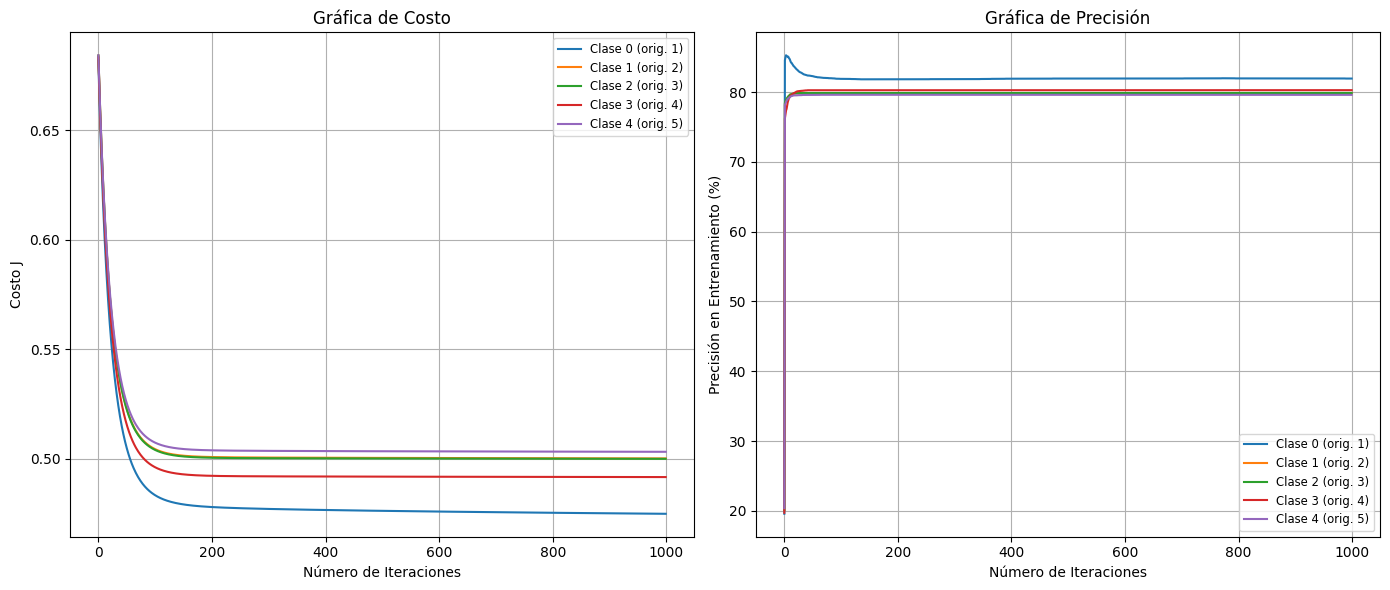

✅ Entrenamiento de los 5 modelos completado.


In [17]:
alpha = 0.1
iteraciones = 1000
all_theta = np.zeros((num_clases, X_train_final.shape[1]))

print("Entrenando modelos One-vs-All...")

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

for c in range(num_clases):
    y_c = (y_train == c).astype(int)
    theta_inicial = np.zeros(X_train_final.shape[1])

    theta_optimizado, historial_J, historial_acc = descensoGradiente(
        X_train_final, y_c, theta_inicial, alpha, iteraciones)

    all_theta[c] = theta_optimizado

    axs[0].plot(np.arange(iteraciones), historial_J, label=f'Clase {c} (orig. {clases_unicas[c]})')
    axs[1].plot(np.arange(iteraciones), historial_acc, label=f'Clase {c} (orig. {clases_unicas[c]})')

axs[0].set_xlabel('Número de Iteraciones')
axs[0].set_ylabel('Costo J')
axs[0].set_title('Gráfica de Costo')
axs[0].legend(loc='upper right', fontsize='small')
axs[0].grid(True)

axs[1].set_xlabel('Número de Iteraciones')
axs[1].set_ylabel('Precisión en Entrenamiento (%)')
axs[1].set_title('Gráfica de Precisión')
axs[1].legend(loc='lower right', fontsize='small')
axs[1].grid(True)

plt.tight_layout()
plt.show()

print("✅ Entrenamiento de los 5 modelos completado.")

5. Predicción, Validación y Precisión Final
Para clasificar los 2300 datos de prueba, calculamos la probabilidad que emite cada uno de los 5 modelos entrenados. La predicción final corresponderá a la clase que obtenga la probabilidad más alta. Finalmente, calculamos el porcentaje de exactitud general.

In [18]:
def predecir_OneVsAll(X, all_theta):
    probabilidades = sigmoide(np.dot(X, all_theta.T))
    predicciones = np.argmax(probabilidades, axis=1)
    return predicciones

y_pred_test = predecir_OneVsAll(X_test_final, all_theta)

exactitud = np.mean(y_pred_test == y_test) * 100

print(f"--- RESULTADOS DE LA VALIDACIÓN (Dataset Multimodal) ---")
print(f"Datos evaluados (20%): {len(y_test)}")
print(f"Predicciones correctas: {np.sum(y_pred_test == y_test)}")
print(f"Precisión del Modelo Multiclase: {exactitud:.2f}%")
print(f"-----------------------------------------------------")

print("\nEjemplo de las primeras 15 predicciones vs Valores Reales:")
for i in range(15):
    clase_real = clases_unicas[y_test[i]]
    clase_pred = clases_unicas[y_pred_test[i]]
    print(f"Instancia {i+1:02d} | Clase Real: {clase_real} | Predicción IA: {clase_pred}")

--- RESULTADOS DE LA VALIDACIÓN (Dataset Multimodal) ---
Datos evaluados (20%): 2300
Predicciones correctas: 608
Precisión del Modelo Multiclase: 26.43%
-----------------------------------------------------

Ejemplo de las primeras 15 predicciones vs Valores Reales:
Instancia 01 | Clase Real: 1 | Predicción IA: 1
Instancia 02 | Clase Real: 5 | Predicción IA: 4
Instancia 03 | Clase Real: 1 | Predicción IA: 1
Instancia 04 | Clase Real: 2 | Predicción IA: 5
Instancia 05 | Clase Real: 4 | Predicción IA: 4
Instancia 06 | Clase Real: 5 | Predicción IA: 5
Instancia 07 | Clase Real: 5 | Predicción IA: 5
Instancia 08 | Clase Real: 4 | Predicción IA: 4
Instancia 09 | Clase Real: 2 | Predicción IA: 2
Instancia 10 | Clase Real: 1 | Predicción IA: 1
Instancia 11 | Clase Real: 5 | Predicción IA: 4
Instancia 12 | Clase Real: 4 | Predicción IA: 5
Instancia 13 | Clase Real: 1 | Predicción IA: 1
Instancia 14 | Clase Real: 2 | Predicción IA: 5
Instancia 15 | Clase Real: 3 | Predicción IA: 5
